In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat data dummy factory_production.csv secara otomatis agar anti-error
np.random.seed(42)
n_samples = 150

dates = pd.date_range(start='2024-01-01', periods=n_samples, freq='D')
shifts = np.random.choice(['Pagi', 'Siang', 'Malam'], size=n_samples)
mesin = np.random.choice(['A', 'B', 'C', 'D'], size=n_samples)
produksi = np.random.randint(100, 500, size=n_samples)
cacat = np.random.randint(0, 30, size=n_samples)
downtime = np.random.randint(0, 120, size=n_samples)
suhu = np.random.uniform(60.0, 95.0, size=n_samples)
kelembaban = np.random.uniform(40.0, 80.0, size=n_samples)

df = pd.DataFrame({
    'Tanggal': dates,
    'Shift': shifts,
    'Mesin': mesin,
    'Jumlah_Produksi': produksi,
    'Jumlah_Cacat': cacat,
    'Downtime (menit)': downtime,
    'Suhu_Mesin': suhu,
    'Kelembaban': kelembaban
})

# Menambahkan sedikit missing value sesuai instruksi soal
df.loc[::15, 'Jumlah_Cacat'] = np.nan
df.loc[::20, 'Downtime (menit)'] = np.nan

# Simpan ke CSV lokal
df.to_csv('factory_production.csv', index=False)

# Tampilkan 10 baris pertama
df.head(10)

,Tanggal,Shift,Mesin,Jumlah_Produksi,Jumlah_Cacat,Downtime (menit),Suhu_Mesin,Kelembaban
0,2024-01-01,Malam,D,437,NaN,NaN,62.969320,45.553087
1,2024-01-02,Pagi,D,459,13.0,49.0,94.532385,65.634990
2,2024-01-03,Malam,B,228,15.0,34.0,73.099478,47.275203
3,2024-01-04,Malam,A,366,13.0,32.0,72.972475,53.826691
4,2024-01-05,Pagi,C,250,11.0,32.0,88.447985,75.871536
5,2024-01-06,Pagi,C,397,18.0,60.0,93.153700,58.958466
6,2024-01-07,Malam,A,198,22.0,50.0,94.510037,66.702310
7,2024-01-08,Siang,C,362,14.0,42.0,86.368236,46.892795
8,2024-01-09,Malam,C,351,27.0,100.0,73.169085,47.691561
9,2024-01-10,Malam,A,243,1.0,11.0,62.922525,41.634745


In [3]:
# Inspeksi Struktur Data
print("=== INFORMASI DATASET ===")
df.info()

print("\n=== STATISTIK DESKRIPSI ===")
display(df.describe())

print("\n=== JUMLAH MISSING VALUE PER KOLOM ===")
print(df.isnull().sum())

=== INFORMASI DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Tanggal           150 non-null    datetime64[us]
 1   Shift             150 non-null    str           
 2   Mesin             150 non-null    str           
 3   Jumlah_Produksi   150 non-null    int32         
 4   Jumlah_Cacat      140 non-null    float64       
 5   Downtime (menit)  142 non-null    float64       
 6   Suhu_Mesin        150 non-null    float64       
 7   Kelembaban        150 non-null    float64       
dtypes: datetime64[us](1), float64(4), int32(1), str(2)
memory usage: 8.9 KB

=== STATISTIK DESKRIPSI ===


,Tanggal,Jumlah_Produksi,Jumlah_Cacat,Downtime (menit),Suhu_Mesin,Kelembaban
count,150,150.000000,140.000000,142.000000,150.000000,150.000000
mean,2024-03-15 12:00:00,301.153333,16.007143,57.753521,78.865262,57.953969
min,2024-01-01 00:00:00,101.000000,0.000000,1.000000,60.397378,40.802848
25%,2024-02-07 06:00:00,211.250000,9.000000,26.250000,69.875264,47.534203
50%,2024-03-15 12:00:00,290.500000,18.000000,55.000000,79.350820,56.444755
75%,2024-04-21 18:00:00,402.500000,23.000000,91.250000,88.712309,66.734874
max,2024-05-29 00:00:00,497.000000,29.000000,119.000000,94.990119,79.598409
std,NaN,115.639090,8.760192,35.557602,10.730774,11.096135



=== JUMLAH MISSING VALUE PER KOLOM ===
Tanggal              0
Shift                0
Mesin                0
Jumlah_Produksi      0
Jumlah_Cacat        10
Downtime (menit)     8
Suhu_Mesin           0
Kelembaban           0
dtype: int64


In [4]:
# Imputasi missing value menggunakan Median (karena tahan terhadap pencilan)
df['Jumlah_Cacat'] = df['Jumlah_Cacat'].fillna(df['Jumlah_Cacat'].median())
df['Downtime (menit)'] = df['Downtime (menit)'].fillna(df['Downtime (menit)'].median())

# Verifikasi ulang bahwa missing value sudah 0
print("=== PERIKSA ULANG MISSING VALUE ===")
print(df.isnull().sum())

=== PERIKSA ULANG MISSING VALUE ===
Tanggal             0
Shift               0
Mesin               0
Jumlah_Produksi     0
Jumlah_Cacat        0
Downtime (menit)    0
Suhu_Mesin          0
Kelembaban          0
dtype: int64


Alasan Pemilihan Metode Imputasi:
Pengisian data hilang pada kolom Jumlah_Cacat dan Downtime (menit) dilakukan menggunakan metode median (nilai tengah). Metode median dipilih daripada mean (rata-rata) karena data operasional pabrik cenderung memiliki variasi ekstrem (pencilan/outlier) pada durasi downtime maupun jumlah produk cacat. Dengan median, nilai estimasi pengisi tidak akan terdistorsi oleh angka ekstrem tersebut.

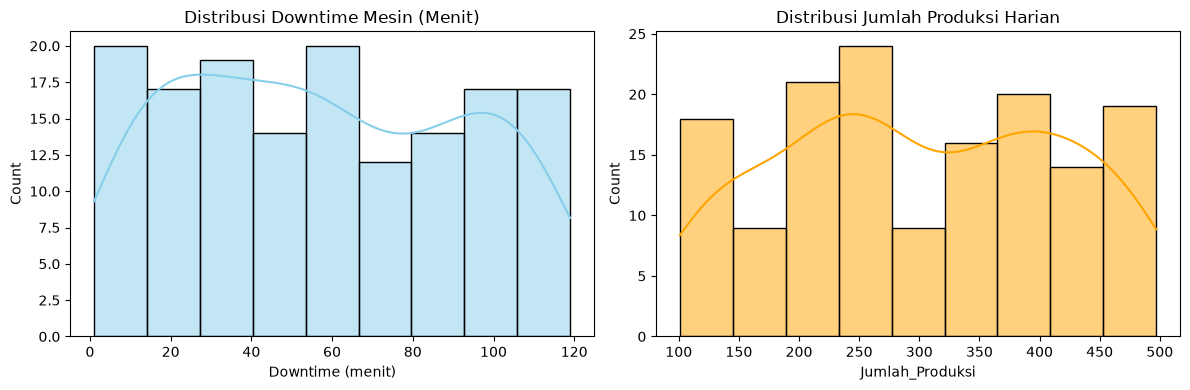

In [5]:
# Visualisasi 1: Histogram Downtime dan Jumlah Produksi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Downtime (menit)'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Downtime Mesin (Menit)')

sns.histplot(df['Jumlah_Produksi'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribusi Jumlah Produksi Harian')

plt.tight_layout()
plt.show()

Insight Visualisasi 1:
Distribusi downtime mesin memperlihatkan bahwa sebagian besar durasi waktu henti berpusat pada durasi pendek hingga menengah, namun terdapat ekor distribusi yang menunjukkan beberapa kejadian downtime panjang di atas 90 menit. Sementara itu, volume produksi harian terdistribusi cukup merata di rentang 100 hingga 500 unit, yang mengindikasikan beban kerja pabrik relatif konsisten sepanjang periode pencatan.

C:\Users\Budi Santosa\AppData\Local\Temp\ipykernel_2436\2792781536.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Shift', y='Jumlah_Cacat', ax=axes[0], palette='Set2')
C:\Users\Budi Santosa\AppData\Local\Temp\ipykernel_2436\2792781536.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Mesin', y='Jumlah_Cacat', ax=axes[1], palette='Set3')


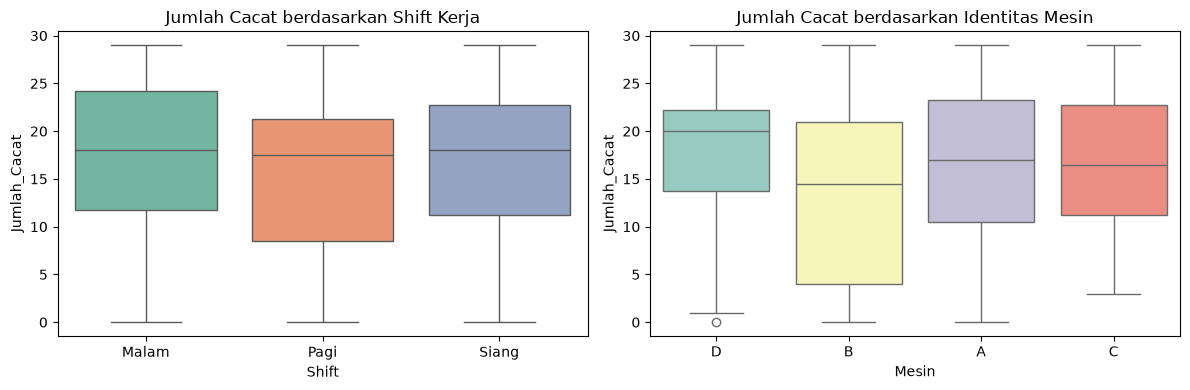

In [6]:
# Visualisasi 2: Boxplot Jumlah Cacat Berdasarkan Shift dan Mesin
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='Shift', y='Jumlah_Cacat', ax=axes[0], palette='Set2')
axes[0].set_title('Jumlah Cacat berdasarkan Shift Kerja')

sns.boxplot(data=df, x='Mesin', y='Jumlah_Cacat', ax=axes[1], palette='Set3')
axes[1].set_title('Jumlah Cacat berdasarkan Identitas Mesin')

plt.tight_layout()
plt.show()

Insight Visualisasi 2:
Persebaran produk cacat cenderung variatif di setiap shift kerja maupun tipe mesin. Tidak terlihat perbedaan ekstrem pada nilai median cacat antar mesin, yang menunjukkan bahwa performa antar mesin relatif homogen. Namun, beberapa shift menunjukkan rentang interkuartil yang lebih lebar, menandakan adanya variabilitas kualitas pada jam operasional tertentu.

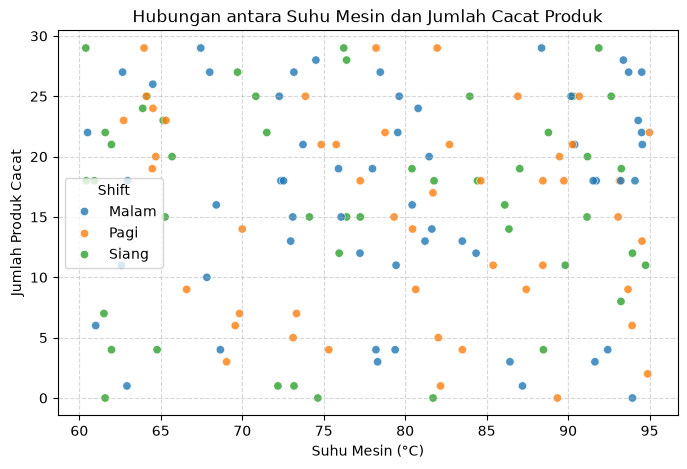

In [7]:
# Visualisasi 3: Scatter Plot Suhu Mesin vs Jumlah Cacat
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Suhu_Mesin', y='Jumlah_Cacat', hue='Shift', palette='tab10', alpha=0.8)
plt.title('Hubungan antara Suhu Mesin dan Jumlah Cacat Produk')
plt.xlabel('Suhu Mesin (°C)')
plt.ylabel('Jumlah Produk Cacat')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Insight Visualisasi 3:

Scatter plot memperlihatkan sebaran titik hubungan antara variabel suhu mesin dengan jumlah produk cacat pada berbagai shift kerja. Tren sebaran titik dapat membantu mengidentifikasi apakah lonjakan suhu mesin berkorelasi langsung terhadap peningkatan tingkat kecacatan produk.

In [8]:
import os
print(os.getcwd())

C:\Users\Budi Santosa\Documents
